In [ ]:
# =========================================================
# ANÁLISIS DE EXCLUSIÓN SOCIAL EN EL SIGLO XXI (V-Dem)
# =========================================================
# CELDA 0 - PRESENTACIÓN DEL PROYECTO
# ---------------------------------------------------------
# Objetivo:
# Analizar la exclusión social durante el siglo XXI utilizando
# la base de datos V-Dem.
#
# Esta libreta desarrolla el flujo completo del análisis:
# 1. Carga de datos.
# 2. Limpieza y preparación.
# 3. Análisis descriptivo.
# 4. Visualizaciones.
# 5. Correlaciones.
# 6. Ranking de países.
# 7. Relación con la democracia.
# 8. Clustering.
# 9. Calidad del dato.
# 10. Exportación de resultados.
# =========================================================

In [ ]:
# =========================================================
# CELDA 1 - IMPORTACIÓN DE LIBRERÍAS
# ---------------------------------------------------------
# Se cargan todas las bibliotecas necesarias para el análisis:
#
# pandas      -> manipulación de datos.
# numpy       -> operaciones numéricas.
# matplotlib  -> creación de gráficos.
# seaborn     -> visualizaciones estadísticas.
#
# Estas librerías serán utilizadas durante todo el notebook.
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# =========================================================
# CELDA 2 - CARGA Y PREPARACIÓN DEL CONJUNTO DE DATOS
# ---------------------------------------------------------
# Se lee el archivo CSV que contiene la información de V-Dem.
#
# Posteriormente se filtran únicamente los años 2000-2023,
# debido a que las variables de exclusión para 2024 y 2025
# aún no han sido completadas por V-Dem.
#
# El resultado es un DataFrame limpio (df21) que será la base
# para todos los análisis posteriores.
# =========================================================

df = pd.read_csv('/content/vdem_exclusion_subset.csv')

df21 = df[(df['year'] >= 2000) & (df['year'] <= 2023)].copy()
print(f"Filas: {df21.shape[0]} | Países: {df21['country_name'].nunique()} | Años: {df21['year'].min()}-{df21['year'].max()}")

Filas: 4278 | Países: 179 | Años: 2000-2023


In [ ]:
# =========================================================
# CELDA 3 - INSPECCIÓN DE DATOS FALTANTES
# ---------------------------------------------------------
# Se calcula el porcentaje de valores faltantes de cada variable.
#
# El objetivo es identificar columnas con alta cantidad de datos
# ausentes y decidir si deben excluirse, conservarse o tratarse
# de forma especial durante el análisis.
#
# Esta revisión evita introducir sesgos mediante imputaciones
# innecesarias.
# =========================================================

missing_pct = (df21.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0])

# e_gdppc, e_pop, e_area tienen mucho missing -> se usan solo cuando
# se necesiten explícitamente (ej. controlar por riqueza), nunca se
# imputan con media/mediana: imputar aquí introduciría sesgo, mejor
# dropear filas puntuales en el análisis que las requiera.

e_area                19.284712
e_gdppc               18.910706
e_pop                 18.910706
v2x_gender             0.981767
v2x_gender_sd          0.981767
v2peapssoc             0.116877
v2xpe_exlsocgr         0.093502
v2xpe_exlgeo           0.093502
v2xpe_exlgender        0.093502
v2xpe_exlgender_sd     0.093502
v2xpe_exlsocgr_sd      0.093502
v2pepwrgeo             0.093502
v2peapsecon            0.093502
v2xpe_exlecon          0.093502
v2xpe_exlpol           0.093502
v2x_libdem             0.046751
dtype: float64


In [ ]:
# =========================================================
# CELDA 4 - ESTADÍSTICAS DESCRIPTIVAS
# ---------------------------------------------------------
# Se obtienen medidas descriptivas de las cinco dimensiones
# principales de exclusión social.
#
# Se calculan:
# - media
# - desviación estándar
# - mínimo
# - máximo
# - percentiles
#
# Esto permite conocer el comportamiento general de cada índice
# antes de realizar análisis más complejos.
# =========================================================

exclusion_cols = ['v2xpe_exlsocgr','v2xpe_exlgender','v2xpe_exlecon','v2xpe_exlpol','v2xpe_exlgeo']
print(df21[exclusion_cols].describe().round(3))

# Escala V-Dem: 0 = sin exclusión, 1 = exclusión total.
# OJO editorial: esto NO es un porcentaje de población excluida,
# es un índice compuesto de percepción experta. Aclarar en el texto.

       v2xpe_exlsocgr  v2xpe_exlgender  v2xpe_exlecon  v2xpe_exlpol  \
count        4274.000         4274.000       4274.000      4274.000   
mean            0.385            0.353          0.402         0.390   
std             0.266            0.247          0.267         0.285   
min             0.011            0.014          0.010         0.009   
25%             0.138            0.115          0.168         0.130   
50%             0.359            0.333          0.400         0.344   
75%             0.607            0.524          0.594         0.626   
max             0.973            0.990          0.982         0.961   

       v2xpe_exlgeo  
count      4274.000  
mean          0.387  
std           0.267  
min           0.021  
25%           0.114  
50%           0.379  
75%           0.607  
max           0.953  


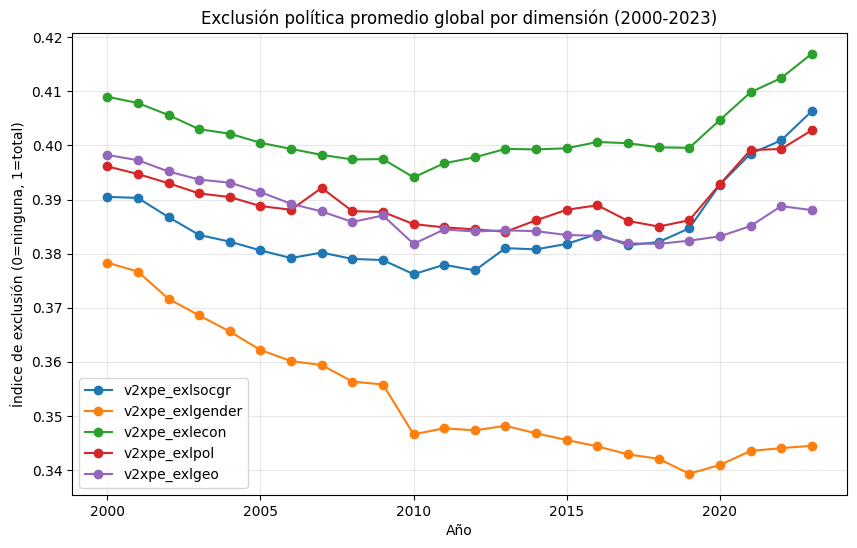

In [ ]:
# =========================================================
# CELDA 5 - EVOLUCIÓN TEMPORAL DE LA EXCLUSIÓN SOCIAL
# ---------------------------------------------------------
# Se calcula el promedio anual mundial para cada dimensión
# de exclusión y posteriormente se representa mediante una
# gráfica de líneas.
#
# El objetivo es observar tendencias globales entre 2000 y
# 2023 e identificar aumentos o disminuciones de la exclusión.
# =========================================================

trend = df21.groupby('year')[exclusion_cols].mean()

plt.figure(figsize=(10,6))
for col in exclusion_cols:
    plt.plot(trend.index, trend[col], marker='o', label=col)
plt.title('Exclusión política promedio global por dimensión (2000-2023)')
plt.xlabel('Año')
plt.ylabel('Índice de exclusión (0=ninguna, 1=total)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('/content/tendencia_global.png', dpi=150, bbox_inches='tight')
plt.show()

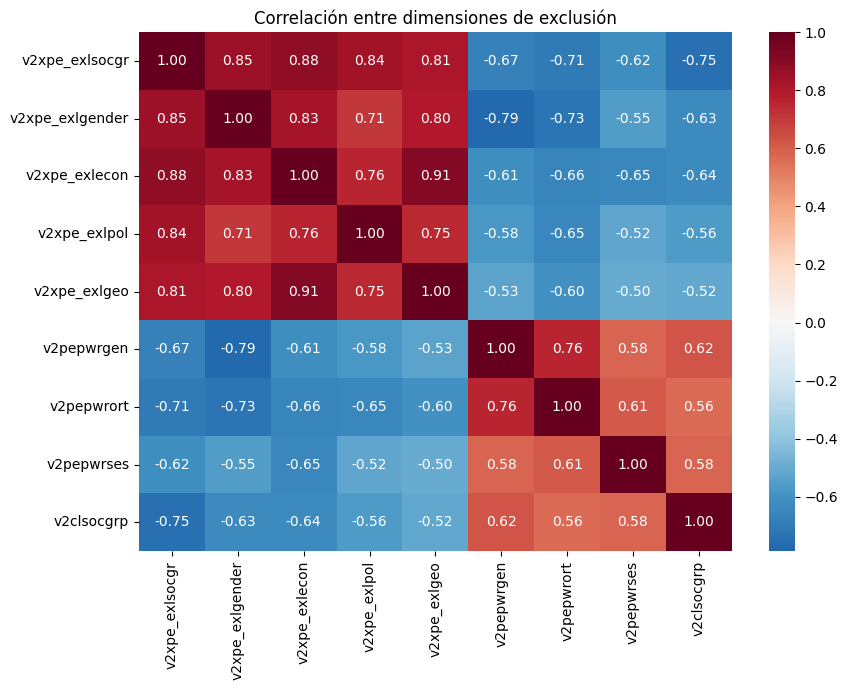

In [ ]:
# =========================================================
# CELDA 6 - MATRIZ DE CORRELACIÓN
# ---------------------------------------------------------
# Se calcula la correlación entre los distintos indicadores
# de exclusión y algunas variables relacionadas con el poder
# político y la estratificación social.
#
# Finalmente se representa mediante un mapa de calor para
# identificar relaciones positivas y negativas entre variables.
# =========================================================

corr = df21[exclusion_cols + ['v2pepwrgen','v2pepwrort','v2pepwrses','v2clsocgrp']].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlación entre dimensiones de exclusión')
plt.tight_layout()
plt.savefig('/content/correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Advertencia: correlaciones altas (>0.7) entre v2xpe_exlsocgr y las
# demás v2xpe_exl* son esperables por diseño metodológico compartido,
# no evidencia sustantiva de que "todo pase junto". No lo presentes
# como hallazgo causal en el artículo.

In [ ]:
# =========================================================
# CELDA 7 - RANKING DE PAÍSES
# ---------------------------------------------------------
# Se calcula el promedio histórico de cada dimensión de
# exclusión por país.
#
# Después se obtiene un indicador promedio general que permite
# ordenar los países desde los mayores niveles de exclusión
# hasta los menores.
#
# Este ranking facilita comparar el desempeño relativo entre
# países.
# =========================================================

ranking = (df21.groupby('country_name')[exclusion_cols]
           .mean()
           .assign(promedio_general=lambda d: d.mean(axis=1))
           .sort_values('promedio_general', ascending=False))

print("PEORES 15 (más exclusión):")
print(ranking.head(15).round(3))
print("\nMEJORES 15 (menos exclusión):")
print(ranking.tail(15).round(3))

PEORES 15 (más exclusión):
                                  v2xpe_exlsocgr  v2xpe_exlgender  \
country_name                                                        
Yemen                                      0.914            0.931   
South Sudan                                0.916            0.811   
Somalia                                    0.808            0.971   
Tajikistan                                 0.856            0.862   
Mauritania                                 0.906            0.750   
Sudan                                      0.909            0.862   
Republic of the Congo                      0.865            0.654   
Iraq                                       0.826            0.877   
Democratic Republic of the Congo           0.780            0.612   
Chad                                       0.831            0.728   
Central African Republic                   0.887            0.623   
Djibouti                                   0.779            0.841   
Equator

Correlación poliarquía vs exclusión social: r=-0.735, p=0.0000


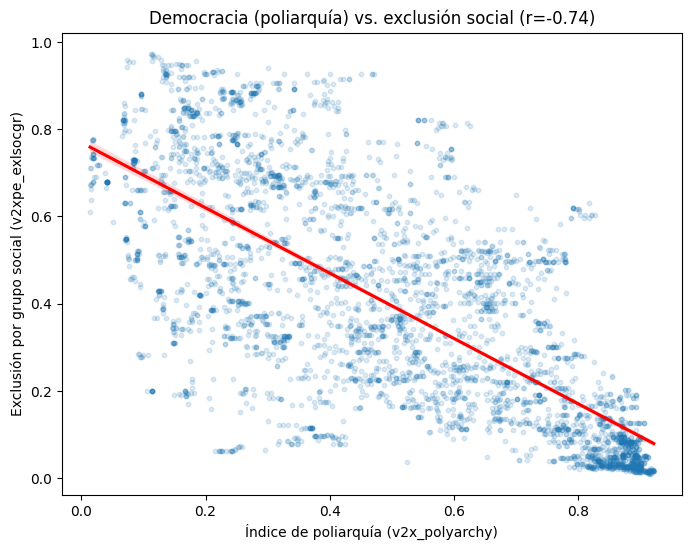

In [ ]:
# =========================================================
# CELDA 8 - EXCLUSIÓN SOCIAL Y DEMOCRACIA
# ---------------------------------------------------------
# Se estudia la relación entre el nivel de democracia
# (Polyarchy Index) y la exclusión social.
#
# Para ello se calcula el coeficiente de correlación de Pearson,
# evaluando si existe una asociación lineal entre ambas
# variables sin asumir causalidad.
# =========================================================

# Hipótesis obvia: países más democráticos excluyen menos. Se comprueba,
# no se asume. Coeficiente de correlación, NO regresión causal.
from scipy.stats import pearsonr

sub = df21.dropna(subset=['v2x_polyarchy','v2xpe_exlsocgr'])
r, p = pearsonr(sub['v2x_polyarchy'], sub['v2xpe_exlsocgr'])
print(f"Correlación poliarquía vs exclusión social: r={r:.3f}, p={p:.4f}")

plt.figure(figsize=(8,6))
sns.regplot(data=sub, x='v2x_polyarchy', y='v2xpe_exlsocgr',
            scatter_kws={'alpha':0.15, 's':10}, line_kws={'color':'red'})
plt.title(f'Democracia (poliarquía) vs. exclusión social (r={r:.2f})')
plt.xlabel('Índice de poliarquía (v2x_polyarchy)')
plt.ylabel('Exclusión por grupo social (v2xpe_exlsocgr)')
plt.savefig('/content/democracia_vs_exclusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Nota crítica para el artículo: una correlación negativa fuerte aquí
# es EXACTAMENTE lo esperable dado que ambos índices comparten insumos
# de codificación (los mismos expertos país-año alimentan varios
# índices V-Dem). No es un hallazgo neutral e independiente; hay que
# decirlo así en el texto, no venderlo como descubrimiento.

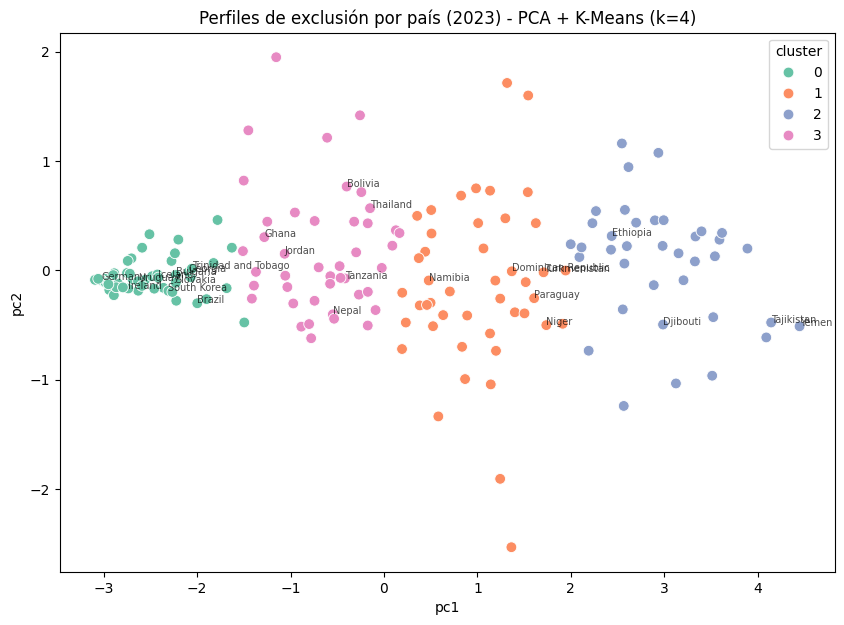

         v2xpe_exlsocgr  v2xpe_exlgender  v2xpe_exlecon  v2xpe_exlpol  \
cluster                                                                 
0                 0.102            0.076          0.114         0.078   
1                 0.528            0.467          0.549         0.488   
2                 0.785            0.659          0.793         0.778   
3                 0.313            0.264          0.315         0.375   

         v2xpe_exlgeo  
cluster                
0               0.088  
1               0.527  
2               0.735  
3               0.300  

Varianza explicada por los 2 componentes: 0.915

Países por cluster:

Cluster 0: ['Sweden', 'Switzerland', 'Japan', 'Poland', 'Brazil', 'United States of America', 'Portugal', 'Argentina', 'South Korea', 'Taiwan', 'Bhutan', 'Canada', 'Australia', 'Chile', 'Costa Rica', 'France', 'Germany', 'Ireland', 'Italy', 'Latvia', 'Netherlands', 'Spain', 'United Kingdom', 'Uruguay', 'Georgia', 'Jamaica', 'Moldova', 'Trinidad

In [ ]:
# =========================================================
# CELDA 9 - CLUSTERING DE PAÍSES
# ---------------------------------------------------------
# Se agrupan los países según sus perfiles de exclusión
# utilizando K-Means.
#
# Antes del agrupamiento:
# - Se normalizan las variables.
# - Se aplica PCA para visualizar los grupos.
#
# El objetivo es identificar patrones similares de exclusión
# entre países.
# =========================================================

# --- CELDA 8: Clustering - perfiles de exclusión por país (2023, último año completo) ---
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

snap = df21[df21['year'] == 2023].dropna(subset=exclusion_cols).copy()

X = StandardScaler().fit_transform(snap[exclusion_cols])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
snap['cluster'] = kmeans.fit_predict(X)

pca = PCA(n_components=2)
coords = pca.fit_transform(X)
snap['pc1'], snap['pc2'] = coords[:,0], coords[:,1]

plt.figure(figsize=(10,7))
sns.scatterplot(data=snap, x='pc1', y='pc2', hue='cluster', palette='Set2', s=60)
for _, row in snap.sample(min(25, len(snap)), random_state=1).iterrows():
    plt.text(row['pc1'], row['pc2'], row['country_name'], fontsize=7, alpha=0.7)
plt.title('Perfiles de exclusión por país (2023) - PCA + K-Means (k=4)')
plt.savefig('/content/clusters_2023.png', dpi=150, bbox_inches='tight')
plt.show()

print(snap.groupby('cluster')[exclusion_cols].mean().round(3))
print("\nVarianza explicada por los 2 componentes:", pca.explained_variance_ratio_.sum().round(3))
print("\nPaíses por cluster:")
for c in sorted(snap['cluster'].unique()):
    print(f"\nCluster {c}:", snap[snap['cluster']==c]['country_name'].tolist())

In [ ]:
# =========================================================
# CELDA 10 - EVALUACIÓN DE LA CONFIABILIDAD DEL DATO
# ---------------------------------------------------------
# Se analiza el desacuerdo entre codificadores utilizando las
# desviaciones estándar reportadas por V-Dem.
#
# Un mayor desacuerdo indica mayor incertidumbre en la medición,
# por lo que esta celda permite evaluar la calidad de la
# información utilizada en el estudio.
# =========================================================

# Ángulo crítico explícito: dónde el dato mismo es más incierto.
sd_cols = ['v2xpe_exlsocgr_sd','v2xpe_exlgender_sd']
reliability = df21.groupby('country_name')[sd_cols].mean().sort_values('v2xpe_exlsocgr_sd', ascending=False)
print("Países con MAYOR desacuerdo entre codificadores expertos (dato menos confiable):")
print(reliability.head(15).round(3))

Países con MAYOR desacuerdo entre codificadores expertos (dato menos confiable):
                    v2xpe_exlsocgr_sd  v2xpe_exlgender_sd
country_name                                             
Peru                            0.364               0.378
Laos                            0.363               0.381
Uzbekistan                      0.363               0.383
Dominican Republic              0.363               0.377
India                           0.362               0.378
Kyrgyzstan                      0.362               0.377
Ukraine                         0.361               0.371
Mongolia                        0.361               0.375
Egypt                           0.361               0.375
Nigeria                         0.360               0.380
South Africa                    0.360               0.379
Indonesia                       0.360               0.373
Mexico                          0.360               0.383
Israel                          0.360            

In [ ]:
# =========================================================
# CELDA 11 - EXPORTACIÓN DE RESULTADOS
# ---------------------------------------------------------
# Se guardan los principales resultados del análisis en archivos
# CSV para facilitar su utilización en informes, artículos o
# análisis posteriores.
#
# Se exportan:
# - Ranking de países.
# - Tendencias anuales.
# - Clusters obtenidos.
#
# Con esta celda finaliza el flujo de trabajo del notebook.
# =========================================================

ranking.to_csv('/content/ranking_paises_exclusion.csv')
trend.to_csv('/content/tendencia_anual.csv')
snap[['country_name','cluster']+exclusion_cols].to_csv('/content/clusters_paises_2023.csv', index=False)
print("Listo: ranking_paises_exclusion.csv, tendencia_anual.csv, clusters_paises_2023.csv")

Listo: ranking_paises_exclusion.csv, tendencia_anual.csv, clusters_paises_2023.csv
